# Read and plot the original source

Same complete `MOI_controlled` readout and plotting options as `read_atst.ipynb`. Source ranges and condition annotations remain explicit; no ATST file is read. Matplotlib plots the source values directly.


In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pandas as pd

readout_id = "MOI_controlled"
rows, curves = [], []

import csv

with Path("read_shared_data/sources/TableS5_growth curve MOI controlled.csv").open(
    encoding="utf-8-sig", newline=""
) as file:
    source_rows = list(csv.reader(file))
header, data = source_rows[0], source_rows[1:]

# Documented source alignment repair: sole orphan value belongs to final blank.
data[-2][67] = data[-1][64]
data = data[:-1]

time = [float(row[0]) for row in data]
counts = {}
for column, label in enumerate(header[1:], 1):
    counts[label] = counts.get(label, 0) + 1
    phage, moi = label.split("_MOI", 1) if "_MOI" in label else ("", "")
    rows.append(
        {
            "type": "blank"
            if label == "blank"
            else "phage_exposed"
            if phage
            else "uninfected_control",
            "phage_id": phage,
            "moi": {"1": "1", "_01": "0.1", "_001": "0.01", "": ""}[moi],
            "replicate": str(counts[label]),
        }
    )
    curves.append(
        pd.Series(
            [float(row[column]) if row[column] else None for row in data], index=time
        )
    )

layout = pd.DataFrame(rows)
layout["curve_id"] = [f"curve_{i}" for i in range(1, len(rows) + 1)]
readings = pd.concat(curves, axis=1).sort_index()
readings.columns = layout["curve_id"]
readings = readings.rename_axis("Time").reset_index()


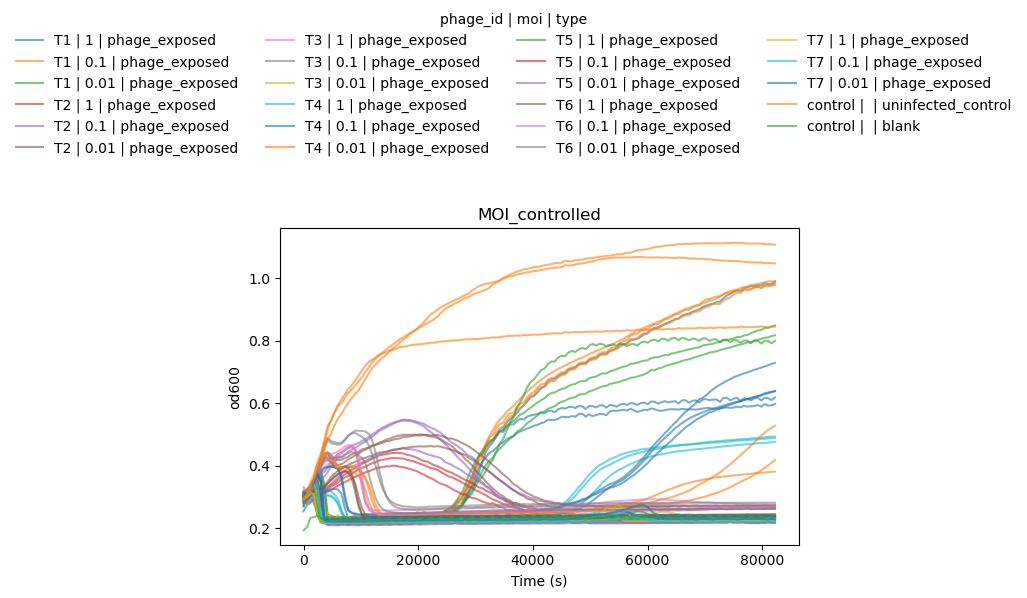

In [2]:
panels = [(None, layout)]
fig, axes = plt.subplots(figsize=(6, 6), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby(
        ["phage_id", "moi", "type"], sort=False
    ):
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = " | ".join(
            "control" if index == 0 and (pd.isna(value) or value == "") else str(value)
            for index, value in enumerate(condition)
        )
        values = readings[group["curve_id"]]
        for index, curve_id in enumerate(group["curve_id"]):
            ax.plot(
                readings["Time"],
                readings[curve_id],
                color=color,
                alpha=0.6,
                label=label if index == 0 else None,
            )
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("od600")
    ax.set_title(readout_id)

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)
legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='phage_id | moi | type', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()
